# Klasifikasi Predikat Nilai Akademik Siswa
### Studi Kasus: UCI Student Performance Dataset (Math + Portuguese)

# IMPORT LIB

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# LOAD DATA + GABUNGKAN DATA

In [3]:
df_mat = pd.read_csv("student-mat.csv", sep=";")
df_por = pd.read_csv("student-por.csv", sep=";")

df_mat["subject"] = "Math"
df_por["subject"] = "Portuguese"

df = pd.concat([df_mat, df_por], ignore_index=True)

print("Jumlah data Math       :", df_mat.shape[0])
print("Jumlah data Portuguese :", df_por.shape[0])
print("Total data gabungan    :", df.shape[0])
df.head()


Jumlah data Math       : 395
Jumlah data Portuguese : 649
Total data gabungan    : 1044


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

In [5]:
# Cek missing value
df.isnull().sum().sort_values(ascending=False).head(10)


school     0
sex        0
age        0
address    0
famsize    0
Pstatus    0
Medu       0
Fedu       0
Mjob       0
Fjob       0
dtype: int64

In [6]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# VISUAL DATA

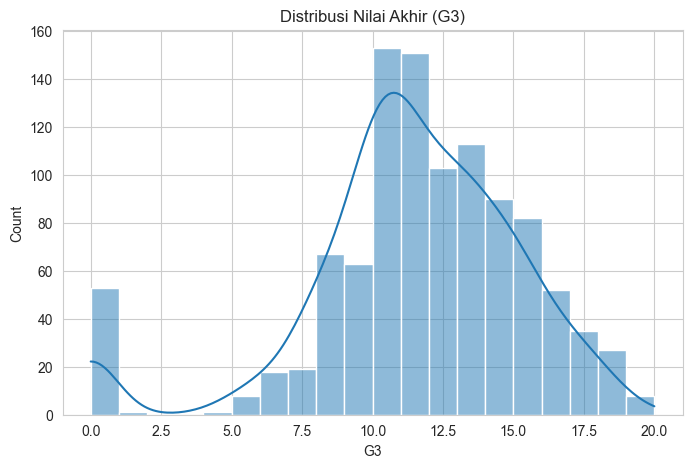

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribusi Nilai Akhir (G3)")
plt.xlabel("G3")
plt.show()


In [8]:
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()["G3"].sort_values(ascending=False)
print(corr)


G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


ubah `G3` (0-20) menjadi 5 kategori predikat, lalu **hapus `G1`, `G2`, `G3`** dari fitur karena ketiganya bocor informasi langsung tentang nilai akhir (data leakage).

predikat
D    304
E    230
C    216
B    172
A    122
Name: count, dtype: int64


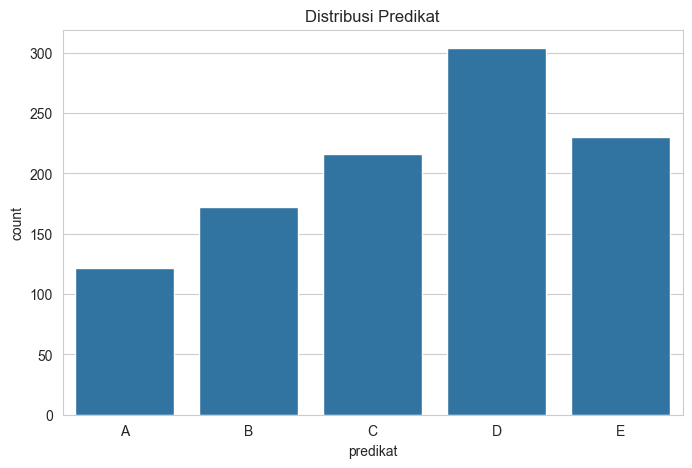

In [9]:
def to_predikat(nilai):
    if nilai >= 16:
        return "A"
    elif nilai >= 14:
        return "B"
    elif nilai >= 12:
        return "C"
    elif nilai >= 10:
        return "D"
    else:
        return "E"

df["predikat"] = df["G3"].apply(to_predikat)

print(df["predikat"].value_counts())
sns.countplot(data=df, x="predikat", order=["A","B","C","D","E"])
plt.title("Distribusi Predikat")
plt.show()


# X Y FEATURE

In [10]:
X = df.drop(columns=["G1", "G2", "G3", "predikat"])
y = df["predikat"]

print("Jumlah fitur:", X.shape[1])
X.head()


Jumlah fitur: 31


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,Math


# ENCODING

In [11]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Kolom kategorikal:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Jumlah fitur setelah encoding:", X_encoded.shape[1])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping kelas:", dict(zip(le.classes_, le.transform(le.classes_))))


Kolom kategorikal: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']
Jumlah fitur setelah encoding: 40
Mapping kelas: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4)}


/tmp/ipykernel_11073/546578155.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


# X Y TRAIN

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Data training :", X_train.shape[0])
print("Data testing  :", X_test.shape[0])


Data training : 835
Data testing  : 209


# SCORE TEST

In [13]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"=== {name} ===")
    print(f"Akurasi: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print("-"*60)


=== Random Forest ===
Akurasi: 0.3541
              precision    recall  f1-score   support

           A       0.28      0.21      0.24        24
           B       0.32      0.29      0.30        35
           C       0.31      0.21      0.25        43
           D       0.33      0.46      0.39        61
           E       0.47      0.48      0.47        46

    accuracy                           0.35       209
   macro avg       0.34      0.33      0.33       209
weighted avg       0.35      0.35      0.35       209

------------------------------------------------------------


# EVAL

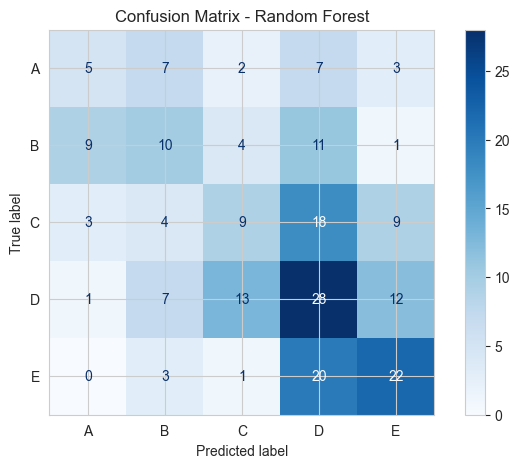

In [14]:
best_model_name = "Random Forest" 
best_model = models["Random Forest"]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


/tmp/ipykernel_11073/3781845278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


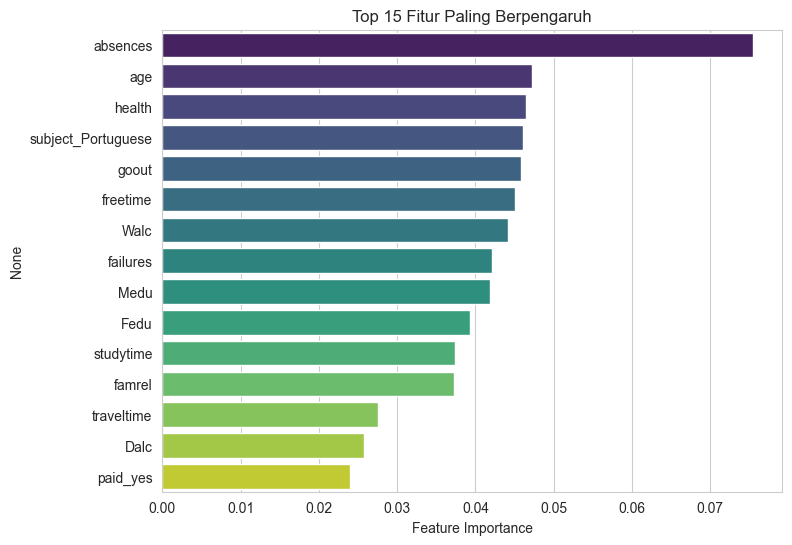

In [15]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Fitur Paling Berpengaruh")
plt.xlabel("Feature Importance")
plt.show()


# OPTIMASI MENGGUNAKAN RandomizedSearchCV

In [16]:
from sklearn.model_selection import RandomizedSearchCV



In [17]:
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # coba 20 kombinasi acak 
    cv=5,               # 5-fold cross validation
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,          # pakai semua core CPU biar cepat
    verbose=1
)

random_search.fit(X_train, y_train)

print("Parameter terbaik:", random_search.best_params_)
print("Akurasi CV terbaik:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


# BEFORE & AFTER OPTIMASI DATA TESTING